# Analysis of Trained SUMO Model Results

This notebook evaluates a trained Multi-Agent PPO model on the SUMO traffic simulation.  
It runs multiple episodes to collect statistics on rewards, queue lengths, waiting times, and throughput.

In [21]:
import os
import sys
from pathlib import Path
from warnings import filterwarnings


filterwarnings("ignore", category=DeprecationWarning)
filterwarnings("ignore", category=FutureWarning)
filterwarnings("ignore", category=UserWarning)

# Add project root to path for imports
PROJECT_ROOT = Path(os.path.abspath('')).parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Add SUMO tools to path
if 'SUMO_HOME' in os.environ:
    tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
    if tools not in sys.path:
        sys.path.append(tools)
else:
    sys.path.append("/usr/share/sumo/tools") # Fallback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import traci
import yaml
from stable_baselines3 import PPO
from tqdm.notebook import tqdm

from agents.train_multi_agent_ppo import make_env

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## Configuration

In [22]:
TARGET_MODEL = 'multi_agent_ppo'
MODEL_PATH = PROJECT_ROOT / 'models' / TARGET_MODEL / 'final_model.zip'
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'multi_agent_ppo.yaml'
# Using simple4 intersection
SUMO_CFG_PATH = PROJECT_ROOT / 'sim' / 'intersections' / 'simple4' / 'simple4.sumocfg'

N_EPISODES = 5
GUI = False  # Set to True to watch simulation (slower)

print(f"Loading model from: {MODEL_PATH}")

Loading model from: /mnt/shared/dev/traffic-zero/models/multi_agent_ppo/final_model.zip


## Define Evaluation Loop

In [23]:
def run_evaluation(model, n_episodes, sumo_cfg_path, config, gui=False, name="Model"):
    """
    Run evaluation episodes for a given model/controller.
    
    Args:
        model: Model with predict(obs, deterministic=True) -> (action, _) interface
        n_episodes: Number of episodes to run
        sumo_cfg_path: Path to SUMO config file
        config: Environment configuration dict
        gui: Whether to show SUMO GUI
        name: Name for progress bar display
        
    Returns:
        df_episodes: DataFrame with per-episode metrics
        df_steps: DataFrame with per-step metrics
    """
    episode_metrics = []
    step_metrics = []
    
    print(f"Running {name} for {n_episodes} episodes...")
    
    for ep in tqdm(range(n_episodes), desc=f"{name} Episodes"):
        try:
            env = make_env(str(sumo_cfg_path), config, gui=gui)
            obs, _ = env.reset()
            
            # Reset controller state if it has one (for NaiveController)
            if hasattr(model, 'current_phase'):
                model.current_phase = 0
            
            done = False
            total_reward = 0
            steps = 0
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated
                
                total_reward += reward
                steps += 1
                
                # Collect Step Metrics via Traci
                try:
                    vehs = traci.vehicle.getIDList()
                    n_vehicles = len(vehs)
                    total_waiting_time = sum(traci.vehicle.getWaitingTime(v) for v in vehs)
                    halting_count = sum(1 for v in vehs if traci.vehicle.getSpeed(v) < 0.1)
                    
                    step_metrics.append({
                        'episode': ep,
                        'step': steps,
                        'reward': reward,
                        'n_vehicles': n_vehicles,
                        'total_waiting_time': total_waiting_time,
                        'halting_count': halting_count
                    })
                except Exception:
                    pass  # Traci might be closed if done just happened
                    
            env.close()
            
            ep_step_metrics = [m for m in step_metrics if m['episode'] == ep]
            episode_metrics.append({
                'episode': ep,
                'total_reward': total_reward,
                'steps': steps,
                'avg_waiting_time': np.mean([m['total_waiting_time'] for m in ep_step_metrics]) if ep_step_metrics else 0,
                'avg_queue': np.mean([m['halting_count'] for m in ep_step_metrics]) if ep_step_metrics else 0
            })
            
        except Exception as e:
            print(f"{name} Episode {ep} failed: {e}")
            try:
                env.close()
            except:
                pass
    
    print(f"{name} evaluation complete.")
    return pd.DataFrame(episode_metrics), pd.DataFrame(step_metrics)

## Run PPO evaluation

In [24]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

model = PPO.load(MODEL_PATH)

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

# Ensure correct SUMO config path if relative
if not os.path.isabs(SUMO_CFG_PATH):
    # Attempt to find it relative to project root if not absolute
    POSSIBLE_PATH = PROJECT_ROOT / 'sim' / 'intersections' / 'simple4' / 'simple4.sumocfg'
    if POSSIBLE_PATH.exists():
        SUMO_CFG_PATH = POSSIBLE_PATH

print(f"SUMO Config: {SUMO_CFG_PATH}")

# Run PPO evaluation
df_eps, df_steps = run_evaluation(
    model=model,
    n_episodes=N_EPISODES,
    sumo_cfg_path=SUMO_CFG_PATH,
    config=config,
    gui=GUI,
    name="PPO"
)

SUMO Config: /mnt/shared/dev/traffic-zero/sim/intersections/simple4/simple4.sumocfg
Running PPO for 5 episodes...


PPO Episodes:   0%|          | 0/5 [00:00<?, ?it/s]

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
PPO evaluation complete.


## Run Naive Controller Baseline

Run a fixed-time controller that cycles phases every 30 seconds as a baseline comparison.

In [25]:
class NaiveController:
    """
    Fixed-time traffic controller that cycles through phases with a fixed duration.
    
    Each phase is held for cycle_time seconds (default 30s) before switching to the next.
    This serves as a baseline comparison for the trained PPO agent.
    """
    def __init__(self, num_agents, num_phases=4, cycle_time=30, min_duration=10, duration_step=10):
        self.num_agents = num_agents
        self.num_phases = num_phases
        self.current_phase = 0
        self.duration_idx = int((cycle_time - min_duration) / duration_step)

    def predict(self, obs, deterministic=True):
        """Return action that sets current phase with fixed duration, then advance phase."""
        phase = self.current_phase
        self.current_phase = (self.current_phase + 1) % self.num_phases
        action_per_agent = [phase, self.duration_idx]
        return np.array(action_per_agent * self.num_agents), None


# Create naive controller - need to get num_agents from a temporary env
temp_env = make_env(str(SUMO_CFG_PATH), config, gui=False)
num_agents = len(temp_env.unwrapped.agent_ids)
temp_env.close()

naive_model = NaiveController(
    num_agents=num_agents,
    num_phases=config['action_config'].get('num_phases', 4),
    min_duration=config['action_config'].get('min_duration', 10),
    duration_step=config['action_config'].get('duration_step', 10)
)

# Run Naive evaluation
df_naive_eps, df_naive_steps = run_evaluation(
    model=naive_model,
    n_episodes=N_EPISODES,
    sumo_cfg_path=SUMO_CFG_PATH,
    config=config,
    gui=GUI,
    name="Naive"
)

 Retrying in 1 seconds
Running Naive for 5 episodes...


Naive Episodes:   0%|          | 0/5 [00:00<?, ?it/s]

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
Naive evaluation complete.


## Results Analysis

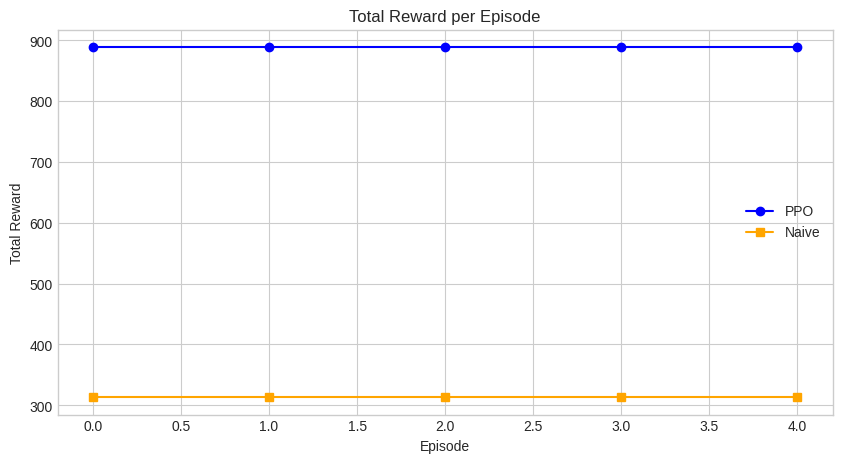

In [26]:
if not df_eps.empty and not df_naive_eps.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_eps['episode'], df_eps['total_reward'], marker='o', label='PPO', color='blue')
    ax.plot(df_naive_eps['episode'], df_naive_eps['total_reward'], marker='s', label='Naive', color='orange')
    ax.set_title('Total Reward per Episode')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend()
    plt.show()
elif not df_eps.empty:
    print("Naive data not available yet. Run naive controller evaluation first.")
else:
    print("No episode data collected.")

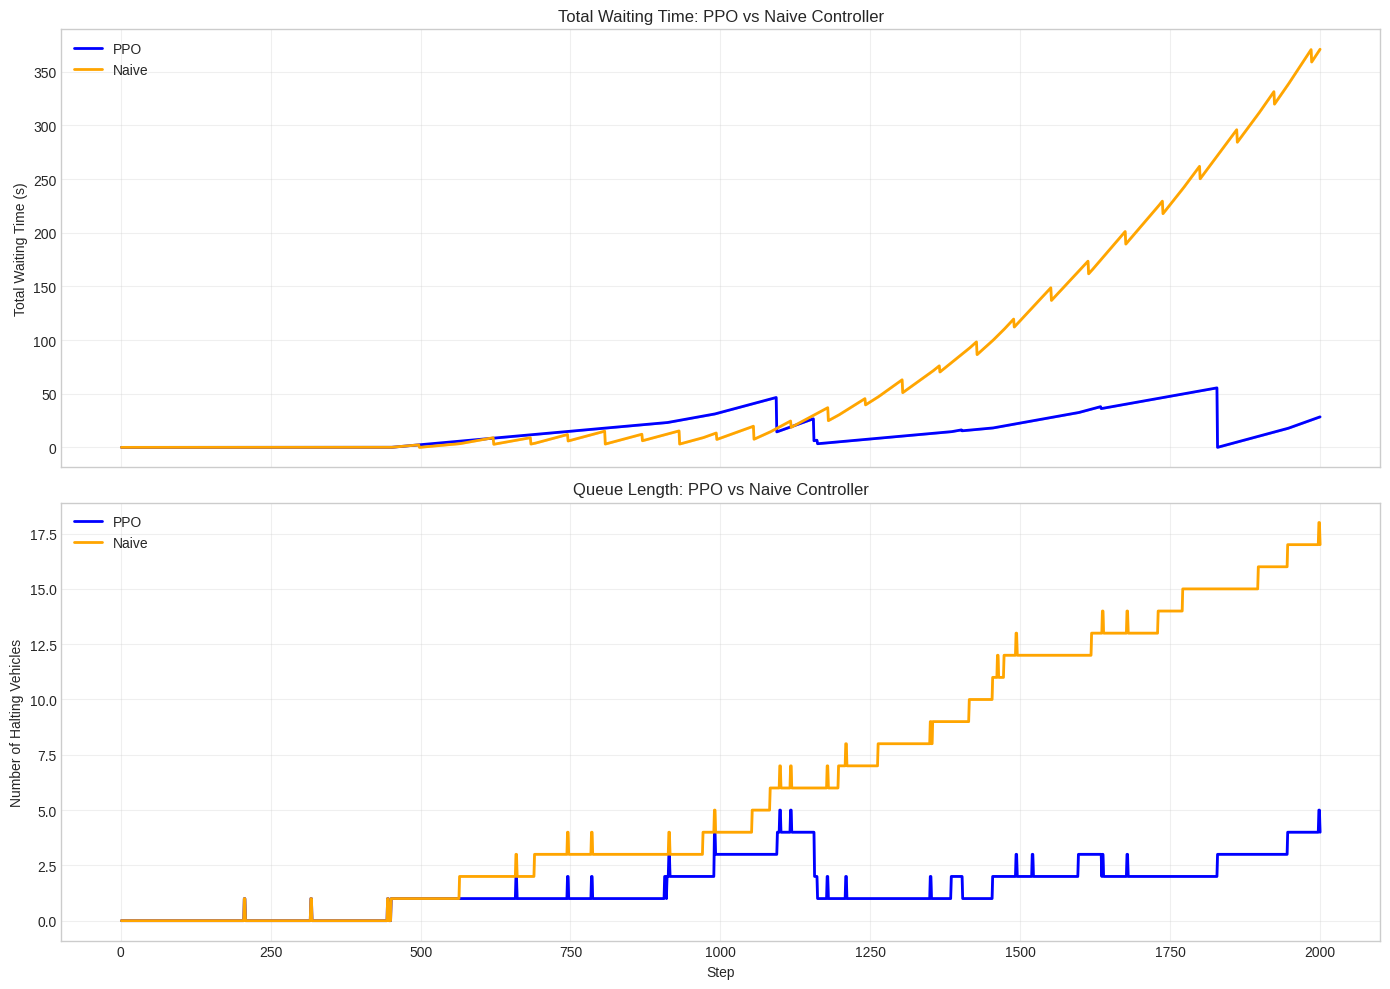

In [27]:
if not df_steps.empty and not df_naive_steps.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Colors for PPO and Naive
    ppo_color = 'blue'
    naive_color = 'orange'
    
    # Aggregate by step (mean across episodes)
    ppo_agg = df_steps.groupby('step').agg({
        'total_waiting_time': ['mean', 'std'],
        'halting_count': ['mean', 'std']
    }).reset_index()
    ppo_agg.columns = ['step', 'wait_mean', 'wait_std', 'queue_mean', 'queue_std']
    
    naive_agg = df_naive_steps.groupby('step').agg({
        'total_waiting_time': ['mean', 'std'],
        'halting_count': ['mean', 'std']
    }).reset_index()
    naive_agg.columns = ['step', 'wait_mean', 'wait_std', 'queue_mean', 'queue_std']
    
    # Plot 1: Total Waiting Time
    axes[0].plot(ppo_agg['step'], ppo_agg['wait_mean'], color=ppo_color, label='PPO', linewidth=2)
    axes[0].fill_between(ppo_agg['step'], 
                         ppo_agg['wait_mean'] - ppo_agg['wait_std'],
                         ppo_agg['wait_mean'] + ppo_agg['wait_std'],
                         color=ppo_color, alpha=0.2)
    
    axes[0].plot(naive_agg['step'], naive_agg['wait_mean'], color=naive_color, label='Naive', linewidth=2)
    axes[0].fill_between(naive_agg['step'],
                         naive_agg['wait_mean'] - naive_agg['wait_std'],
                         naive_agg['wait_mean'] + naive_agg['wait_std'],
                         color=naive_color, alpha=0.2)
    
    axes[0].set_ylabel('Total Waiting Time (s)')
    axes[0].set_title('Total Waiting Time: PPO vs Naive Controller')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Queue Length (Halting Vehicles)
    axes[1].plot(ppo_agg['step'], ppo_agg['queue_mean'], color=ppo_color, label='PPO', linewidth=2)
    axes[1].fill_between(ppo_agg['step'],
                         ppo_agg['queue_mean'] - ppo_agg['queue_std'],
                         ppo_agg['queue_mean'] + ppo_agg['queue_std'],
                         color=ppo_color, alpha=0.2)
    
    axes[1].plot(naive_agg['step'], naive_agg['queue_mean'], color=naive_color, label='Naive', linewidth=2)
    axes[1].fill_between(naive_agg['step'],
                         naive_agg['queue_mean'] - naive_agg['queue_std'],
                         naive_agg['queue_mean'] + naive_agg['queue_std'],
                         color=naive_color, alpha=0.2)
    
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Number of Halting Vehicles')
    axes[1].set_title('Queue Length: PPO vs Naive Controller')
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No step data collected.")

In [28]:
if not df_eps.empty and not df_naive_eps.empty:
    print("Summary Statistics Comparison:")
    print("=" * 60)
    
    summary = pd.DataFrame({
        'Metric': ['Total Reward', 'Avg Waiting Time (s)', 'Avg Queue Length'],
        'PPO Mean': [
            f"{df_eps['total_reward'].mean():.2f} ± {df_eps['total_reward'].std():.2f}",
            f"{df_eps['avg_waiting_time'].mean():.2f} ± {df_eps['avg_waiting_time'].std():.2f}",
            f"{df_eps['avg_queue'].mean():.2f} ± {df_eps['avg_queue'].std():.2f}"
        ],
        'Naive Mean': [
            f"{df_naive_eps['total_reward'].mean():.2f} ± {df_naive_eps['total_reward'].std():.2f}",
            f"{df_naive_eps['avg_waiting_time'].mean():.2f} ± {df_naive_eps['avg_waiting_time'].std():.2f}",
            f"{df_naive_eps['avg_queue'].mean():.2f} ± {df_naive_eps['avg_queue'].std():.2f}"
        ],
        'Improvement': [
            f"{((df_eps['total_reward'].mean() - df_naive_eps['total_reward'].mean()) / abs(df_naive_eps['total_reward'].mean()) * 100):.1f}%",
            f"{((df_naive_eps['avg_waiting_time'].mean() - df_eps['avg_waiting_time'].mean()) / df_naive_eps['avg_waiting_time'].mean() * 100):.1f}%",
            f"{((df_naive_eps['avg_queue'].mean() - df_eps['avg_queue'].mean()) / df_naive_eps['avg_queue'].mean() * 100):.1f}%"
        ]
    })
    print(summary.to_string(index=False))
else:
    print("No stats available.")

Summary Statistics Comparison:
              Metric      PPO Mean    Naive Mean Improvement
        Total Reward 889.04 ± 0.00 313.47 ± 0.00      183.6%
Avg Waiting Time (s)  16.01 ± 0.00  73.82 ± 0.00       78.3%
    Avg Queue Length   1.45 ± 0.00   6.06 ± 0.00       76.1%


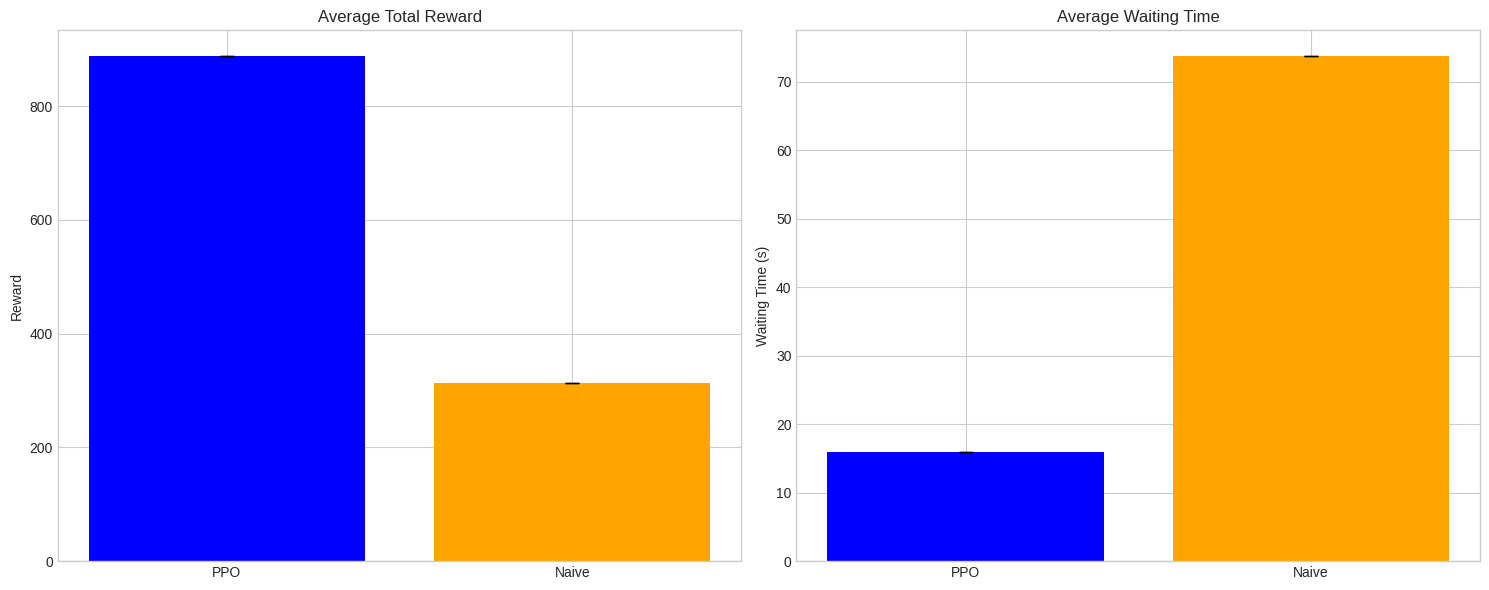

             Metric    PPO Mean  Naive Mean
0      Total Reward  889.042943  313.471957
1  Avg Waiting Time   16.007750   73.817225
2  Avg Queue Length    1.450500    6.060500


In [29]:
if not df_eps.empty and not df_naive_eps.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Total Reward Comparison
    axes[0].bar(['PPO', 'Naive'], [df_eps['total_reward'].mean(), df_naive_eps['total_reward'].mean()], 
                yerr=[df_eps['total_reward'].std(), df_naive_eps['total_reward'].std()], capsize=5, color=['blue', 'orange'])
    axes[0].set_title('Average Total Reward')
    axes[0].set_ylabel('Reward')
    
    # Waiting Time Comparison
    axes[1].bar(['PPO', 'Naive'], [df_eps['avg_waiting_time'].mean(), df_naive_eps['avg_waiting_time'].mean()], 
                yerr=[df_eps['avg_waiting_time'].std(), df_naive_eps['avg_waiting_time'].std()], capsize=5, color=['blue', 'orange'])
    axes[1].set_title('Average Waiting Time')
    axes[1].set_ylabel('Waiting Time (s)')
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison table
    summary = pd.DataFrame({
        'Metric': ['Total Reward', 'Avg Waiting Time', 'Avg Queue Length'],
        'PPO Mean': [df_eps['total_reward'].mean(), df_eps['avg_waiting_time'].mean(), df_eps['avg_queue'].mean()],
        'Naive Mean': [df_naive_eps['total_reward'].mean(), df_naive_eps['avg_waiting_time'].mean(), df_naive_eps['avg_queue'].mean()]
    })
    print(summary)
else:
    print("Insufficient data for comparison.")